# Chapter 128 — Vector Length (Norm)

> **Prerequisites:** Scalar Multiplication (ch126), Vector Representation (ch124), distance between points (ch094)
> **You will learn:**
> - The Euclidean norm and how it generalizes 2D distance
> - Other norms: L1, L∞, and the general Lp family
> - Why norms are the correct measure of vector magnitude
> - Applications: normalization, regularization in ML

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The **norm** of a vector is its length — a single non-negative number that measures how "big" the vector is. For a 2D vector, the Euclidean norm is the familiar distance formula from ch094.

But "length" can be measured in different ways. The Euclidean norm (L2) uses the Pythagorean theorem. The L1 norm counts total component magnitude. The L∞ norm looks at the largest component. Each norm defines a different geometry.

Norms appear throughout ML: gradient magnitudes, regularization penalties, similarity measures, and stopping criteria all involve norms.

**Common misconception:** The norm of a vector is not the same as the sum of its components. It is the square root of the sum of squared components (for L2).

---

## 2. Intuition & Mental Models

**Geometric model:** The L2 norm is the straight-line distance from the origin to the tip of the arrow. It's what a ruler would measure.

**City block model (L1):** Imagine navigating a grid city. The L1 norm is how many blocks you must walk (no diagonal movement). Also called the Manhattan distance.

**Worst-case model (L∞):** The L∞ norm is the maximum absolute component. It answers: "what is the worst-case coordinate?"

**Scaling property:** Recall from ch126 (Scalar Multiplication) that scaling a vector by $c$ should scale its length by $|c|$. Any valid norm must satisfy this.

---

## 3. Visualization

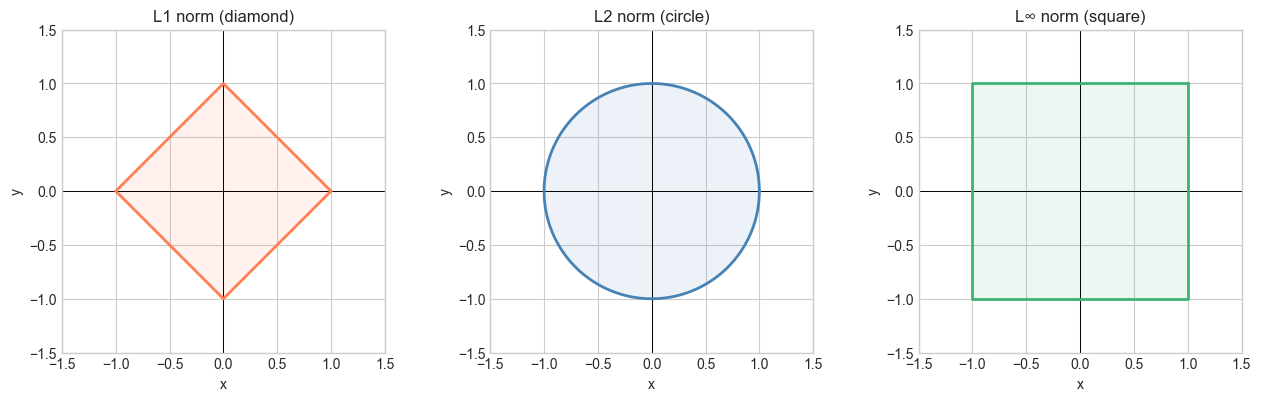

In [1]:
# --- Visualization: Unit circles under different norms ---
# All vectors of norm 1 under L1, L2, Linf
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

theta = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ['L1 norm (diamond)', 'L2 norm (circle)', 'L∞ norm (square)']

for ax, title in zip(axes, titles):
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')

# L2: unit circle
axes[1].plot(np.cos(theta), np.sin(theta), 'steelblue', lw=2)
axes[1].fill(np.cos(theta), np.sin(theta), alpha=0.1, color='steelblue')

# L1: diamond |x|+|y|=1  => parameterize as convex hull of (±1,0),(0,±1)
l1_pts = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])
axes[0].plot(l1_pts[:,0], l1_pts[:,1], 'coral', lw=2)
axes[0].fill(l1_pts[:,0], l1_pts[:,1], alpha=0.1, color='coral')

# L∞: square max(|x|,|y|)=1
sq = np.array([[1,1],[-1,1],[-1,-1],[1,-1],[1,1]])
axes[2].plot(sq[:,0], sq[:,1], 'mediumseagreen', lw=2)
axes[2].fill(sq[:,0], sq[:,1], alpha=0.1, color='mediumseagreen')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

For **v** ∈ ℝⁿ:

$$\|\mathbf{v}\|_2 = \sqrt{\sum_{i=1}^n v_i^2} \qquad \text{(Euclidean / L2 norm)}$$

$$\|\mathbf{v}\|_1 = \sum_{i=1}^n |v_i| \qquad \text{(Manhattan / L1 norm)}$$

$$\|\mathbf{v}\|_\infty = \max_i |v_i| \qquad \text{(Chebyshev / L∞ norm)}$$

$$\|\mathbf{v}\|_p = \left(\sum_{i=1}^n |v_i|^p\right)^{1/p} \qquad \text{(Lp norm, } p \geq 1\text{)}$$

**Norm axioms.** Any valid norm $\|\cdot\|$ must satisfy:
1. $\|\mathbf{v}\| \geq 0$, with equality iff $\mathbf{v} = \mathbf{0}$
2. $\|c\mathbf{v}\| = |c|\|\mathbf{v}\|$ (scaling)
3. $\|\mathbf{u} + \mathbf{v}\| \leq \|\mathbf{u}\| + \|\mathbf{v}\|$ (triangle inequality)

In [2]:
# --- Mathematical Formulation: compute all norms ---
import numpy as np

def norm_l1(v):
    """L1 norm: sum of absolute values."""
    return np.sum(np.abs(v))

def norm_l2(v):
    """L2 norm: Euclidean length."""
    return np.sqrt(np.sum(v**2))

def norm_linf(v):
    """L-infinity norm: max absolute component."""
    return np.max(np.abs(v))

def norm_lp(v, p):
    """General Lp norm."""
    return np.sum(np.abs(v)**p)**(1/p)

v = np.array([3.0, -4.0, 0.0, 1.0])

print("v =", v)
print(f"L1:   {norm_l1(v):.4f}  (NumPy: {np.linalg.norm(v, 1):.4f})")
print(f"L2:   {norm_l2(v):.4f}  (NumPy: {np.linalg.norm(v, 2):.4f})")
print(f"Linf: {norm_linf(v):.4f}  (NumPy: {np.linalg.norm(v, np.inf):.4f})")

print("\nLp norms for p = 1, 2, 3, 10, 100:")
for p in [1, 2, 3, 10, 100]:
    print(f"  p={p:3d}: {norm_lp(v, p):.6f}")

v = [ 3. -4.  0.  1.]
L1:   8.0000  (NumPy: 8.0000)
L2:   5.0990  (NumPy: 5.0990)
Linf: 4.0000  (NumPy: 4.0000)

Lp norms for p = 1, 2, 3, 10, 100:
  p=  1: 8.000000
  p=  2: 5.099020
  p=  3: 4.514357
  p= 10: 4.021975
  p=100: 4.000000


## 5. Python Implementation

In [3]:
# --- Implementation: norm_properties verification ---
import numpy as np

def verify_norm_axioms(v, u, c=2.5, p=2):
    """
    Verify the three norm axioms for Lp norm.

    Args:
        v, u: ndarray shape (n,)
        c: scalar
        p: norm order
    """
    norm = lambda x: np.linalg.norm(x, p)

    # Axiom 1: non-negativity
    ax1 = norm(v) >= 0
    zero_zero = np.allclose(norm(np.zeros_like(v)), 0)

    # Axiom 2: scaling
    ax2 = np.isclose(norm(c * v), abs(c) * norm(v))

    # Axiom 3: triangle inequality
    ax3 = norm(u + v) <= norm(u) + norm(v) + 1e-10  # small tolerance

    print(f"Lp norm with p={p}")
    print(f"  Axiom 1 (non-negative):      {ax1}")
    print(f"  Axiom 1 (zero iff zero vec): {zero_zero}")
    print(f"  Axiom 2 (scaling):           {ax2}")
    print(f"  Axiom 3 (triangle ineq):     {ax3}")
    print(f"    ||u+v||={norm(u+v):.4f}  ||u||+||v||={norm(u)+norm(v):.4f}")


v = np.array([3.0, -1.0, 2.0])
u = np.array([1.0, 4.0, -1.0])

for p in [1, 2, np.inf]:
    verify_norm_axioms(v, u, c=2.5, p=p)
    print()

Lp norm with p=1
  Axiom 1 (non-negative):      True
  Axiom 1 (zero iff zero vec): True
  Axiom 2 (scaling):           True
  Axiom 3 (triangle ineq):     True
    ||u+v||=8.0000  ||u||+||v||=12.0000

Lp norm with p=2
  Axiom 1 (non-negative):      True
  Axiom 1 (zero iff zero vec): True
  Axiom 2 (scaling):           True
  Axiom 3 (triangle ineq):     True
    ||u+v||=5.0990  ||u||+||v||=7.9843

Lp norm with p=inf
  Axiom 1 (non-negative):      True
  Axiom 1 (zero iff zero vec): True
  Axiom 2 (scaling):           True
  Axiom 3 (triangle ineq):     True
    ||u+v||=4.0000  ||u||+||v||=7.0000



## 6. Experiments

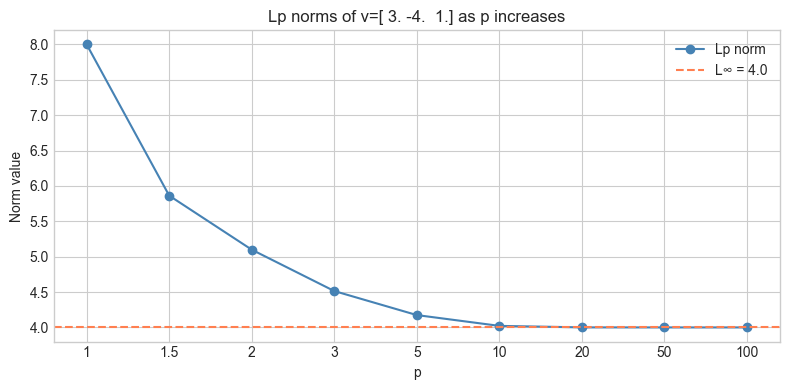

In [4]:
# --- Experiment 1: Lp norm converges to L-infinity as p → ∞ ---
# Hypothesis: as p grows, Lp norm approaches the max absolute component.
# Try changing: the vector v.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

v = np.array([3.0, -4.0, 1.0])  # <-- modify

p_values = [1, 1.5, 2, 3, 5, 10, 20, 50, 100]
norms = [np.sum(np.abs(v)**p)**(1/p) for p in p_values]
linf = np.max(np.abs(v))

plt.figure(figsize=(8, 4))
plt.plot(range(len(p_values)), norms, 'o-', color='steelblue', label='Lp norm')
plt.axhline(linf, color='coral', linestyle='--', label=f'L∞ = {linf}')
plt.xticks(range(len(p_values)), [str(p) for p in p_values])
plt.xlabel('p'); plt.ylabel('Norm value')
plt.title(f'Lp norms of v={v} as p increases')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# --- Experiment 2: Scaling law ||c*v|| = |c| * ||v|| ---
# Hypothesis: this holds exactly for any norm.
# Try changing: the norm order p.
import numpy as np

v = np.array([1.0, -2.0, 3.0, 0.5])
P = 2  # <-- modify: try 1, 3, np.inf

scalars = np.linspace(-3, 3, 13)
for c in scalars:
    lhs = np.linalg.norm(c * v, P)
    rhs = abs(c) * np.linalg.norm(v, P)
    print(f"c={c:5.1f}  ||cv||={lhs:.4f}  |c|*||v||={rhs:.4f}  match={np.isclose(lhs, rhs)}")

c= -3.0  ||cv||=11.3248  |c|*||v||=11.3248  match=True
c= -2.5  ||cv||=9.4373  |c|*||v||=9.4373  match=True
c= -2.0  ||cv||=7.5498  |c|*||v||=7.5498  match=True
c= -1.5  ||cv||=5.6624  |c|*||v||=5.6624  match=True
c= -1.0  ||cv||=3.7749  |c|*||v||=3.7749  match=True
c= -0.5  ||cv||=1.8875  |c|*||v||=1.8875  match=True
c=  0.0  ||cv||=0.0000  |c|*||v||=0.0000  match=True
c=  0.5  ||cv||=1.8875  |c|*||v||=1.8875  match=True
c=  1.0  ||cv||=3.7749  |c|*||v||=3.7749  match=True
c=  1.5  ||cv||=5.6624  |c|*||v||=5.6624  match=True
c=  2.0  ||cv||=7.5498  |c|*||v||=7.5498  match=True
c=  2.5  ||cv||=9.4373  |c|*||v||=9.4373  match=True
c=  3.0  ||cv||=11.3248  |c|*||v||=11.3248  match=True


## 7. Exercises

**Easy 1.** Compute the L1, L2, and L∞ norms of **v** = (1, −2, 2). *(Expected: L1=5, L2=3, L∞=2)*

**Easy 2.** Normalize **v** = (3, 0, 4) using the L2 norm. Verify that the result has L2 norm = 1.

**Medium 1.** Generate 1000 random 2D vectors. For each, compute L1 and L2 norms. Plot L1 vs L2. What is the relationship? What are the theoretical bounds? *(Hint: for any **v** in ℝ²: L2 ≤ L1 ≤ √2 · L2)*

**Medium 2.** In machine learning, L1 regularization adds $\lambda \|\mathbf{w}\|_1$ to the loss, and L2 adds $\lambda \|\mathbf{w}\|_2^2$. For **w** = (3, 0.1, 0.01, −0.5), compute both penalties for λ = 0.1. Which penalizes the large components more severely?

**Hard.** Prove the triangle inequality for the L2 norm: $\|\mathbf{u} + \mathbf{v}\|_2 \leq \|\mathbf{u}\|_2 + \|\mathbf{v}\|_2$. Use the Cauchy-Schwarz inequality $|\mathbf{u}^T\mathbf{v}| \leq \|\mathbf{u}\|\|\mathbf{v}\|$ *(which you will prove in ch131)*.

---

## 8. Mini Project

In [6]:
# --- Mini Project: Nearest Neighbor Classifier ---
# Problem: Given a set of labeled 2D points, classify a new point
#          by finding its nearest neighbor under L1, L2, and Linf.
# Task: implement the classifier and show how the choice of norm affects classification.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(7)

# Class A: centered at (1, 1)
# Class B: centered at (4, 3)
class_A = np.random.randn(20, 2) + np.array([1, 1])
class_B = np.random.randn(20, 2) + np.array([4, 3])

points = np.vstack([class_A, class_B])
labels = np.array(['A']*20 + ['B']*20)

query = np.array([2.5, 2.0])  # point to classify

def nearest_neighbor(points, labels, query, p):
    """
    Find the nearest neighbor of query in points under Lp norm.

    Args:
        points: ndarray shape (n, d)
        labels: list of length n
        query:  ndarray shape (d,)
        p: norm order

    Returns:
        (label, distance, idx)
    """
    diffs = points - query  # shape (n, d)
    distances = np.linalg.norm(diffs, ord=p, axis=1)
    idx = np.argmin(distances)
    return labels[idx], distances[idx], idx


for p_name, p_val in [('L1', 1), ('L2', 2), ('L∞', np.inf)]:
    label, dist, idx = nearest_neighbor(points, labels, query, p_val)
    print(f"{p_name}: nearest is class {label} at distance {dist:.4f}")

L1: nearest is class B at distance 0.3564
L2: nearest is class B at distance 0.3105
L∞: nearest is class B at distance 0.3064


## 9. Summary & Connections

- The L2 (Euclidean) norm is the standard measure of vector length: $\sqrt{\sum v_i^2}$.
- L1 norm = sum of absolute values; L∞ norm = max absolute value.
- Any norm must satisfy: non-negativity, scaling ($\|cv\| = |c|\|v\|$), and triangle inequality.
- As $p \to \infty$, Lp norm converges to L∞.

**Backward connection:** The L2 norm formula $\sqrt{v_x^2 + v_y^2}$ is exactly the distance formula from ch094, applied to the displacement vector from the origin.

**Forward connections:**
- This will reappear in ch129 — Distance in Vector Space, where norm(u − v) becomes the distance between two vectors.
- This will reappear in ch132 — Geometric Meaning of Dot Product, where $\mathbf{v}^T\mathbf{v} = \|\mathbf{v}\|_2^2$.
- This will reappear in ch175 — Linear Regression via Matrix Algebra, where we minimize $\|A\mathbf{x} - \mathbf{b}\|_2^2$.